In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("oil_sales_assignment_dataset.csv")
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [4]:
print(df.tail())
print(len(df))
print(len(df.columns))
print("Numerical:", (df.select_dtypes(include='number').columns))
print("Categorical:", (df.select_dtypes(include='object').columns))



          city                                         store_name  \
1995     TABUK       HM No  99317  GS-CENTER-TABUK MAIN RD  TABUK   
1996   AL AHSA   HM No  85390  GS-CENTER-AL AHSA MAIN RD  AL AHSA   
1997  AL KHARJ  HM No  90740  GS-CENTER-AL KHARJ MAIN RD  AL K...   
1998    RIYADH     HM No  52893  GS-CENTER-RIYADH MAIN RD  RIYADH   
1999    JEDDAH     HM No  73689  GS-CENTER-JEDDAH MAIN RD  JEDDAH   

        manufacturer   brand      class   size                        sku  \
1995  NAJDI CONSUMER    LARA    COCONUT   0.5L  LARA COCONUT 0.5L PREMIUM   
1996   BLUE OASIS CO    LARA  SUNFLOWER     3L          LARA SUNFLOWER 3L   
1997      NOVA FOODS    NOUR  SUNFLOWER   2.9L        NOUR SUNFLOWER 2.9L   
1998      NOVA FOODS   NAJMA       CORN  0.75L       NAJMA CORN 0.75L ECO   
1999  NAJDI CONSUMER  BAYTNA    COCONUT   1.8L    BAYTNA COCONUT 1.8L ECO   

     price_bracket  year  month  value_sales  volume_sales  average_price  
1995         31-40  2024     11         74.4  

In [5]:
print(df.isnull().sum())
print(df.describe())

city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64
              year        month  value_sales  volume_sales  average_price
count  2000.000000  2000.000000  2000.000000   2000.000000    2000.000000
mean   2022.990500     6.639500   614.839355      9.972100      60.990230
std       0.820211     3.468942   750.794991      9.862369      29.457029
min    2022.000000     1.000000     6.960000      0.500000      11.000000
25%    2022.000000     4.000000   132.000000      2.900000      37.337500
50%    2023.000000     7.000000   368.320000      7.000000      61.000000
75%    2024.000000    10.000000   794.100000     13.800000      81.000000
max    2024.000000    12.000000  6253.200000     81.700000     140.000000


In [6]:
le = LabelEncoder()
cols = ['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku', 'price_bracket']
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,1,302,5,3,1,3,537,2,2024,12,830.86,30.1,27.6
1,2,237,6,4,0,1,648,4,2024,10,373.10,9.1,41.0
2,8,1487,0,0,3,3,93,0,2023,1,171.70,1.7,101.0
3,3,1832,6,5,2,2,864,6,2022,2,1226.10,20.1,61.0
4,5,258,3,5,4,7,944,8,2024,2,996.30,12.3,81.0


In [7]:
X_univariate = df[['average_price']] 
y = df['value_sales']
X_train_uni, X_test_uni, y_train, y_test = train_test_split( X_univariate, y, test_size=0.2, random_state=42 ) 
print(f"Training set size: {X_train_uni.shape[0]}") 
print(f"Test set size: {X_test_uni.shape[0]}") 

Training set size: 1600
Test set size: 400


In [8]:
 
uni_model = LinearRegression() 
uni_model.fit(X_train_uni, y_train)
print("Univariate Linear Regression Model:") 
print(f"Equation: sales_Value = ${uni_model.intercept_:,.2f} + ${uni_model.coef_[0]:,.2f} * average_price") 
print(f"\nInterpretation: Each $1 increase in average_price increases value_sales by ${uni_model.coef_[0]:,.2f}")

Univariate Linear Regression Model:
Equation: sales_Value = $-27.28 + $10.51 * average_price

Interpretation: Each $1 increase in average_price increases value_sales by $10.51


In [9]:
y_pred_uni_train = uni_model.predict(X_train_uni) 
y_pred_uni_test = uni_model.predict(X_test_uni) 

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_uni_train)) 
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_uni_test)) 
train_r2 = r2_score(y_train, y_pred_uni_train) 
test_r2 = r2_score(y_test, y_pred_uni_test) 
print("Univariate Model Performance:") 
print(f"Training RMSE: ${train_rmse:,.2f}") 
print(f"Test RMSE: ${test_rmse:,.2f}") 
print(f"Training R² Score: {train_r2:.4f}") 
print(f"Test R² Score: {test_r2:.4f}") 

Univariate Model Performance:
Training RMSE: $687.86
Test RMSE: $674.03
Training R² Score: 0.1735
Test R² Score: 0.1380


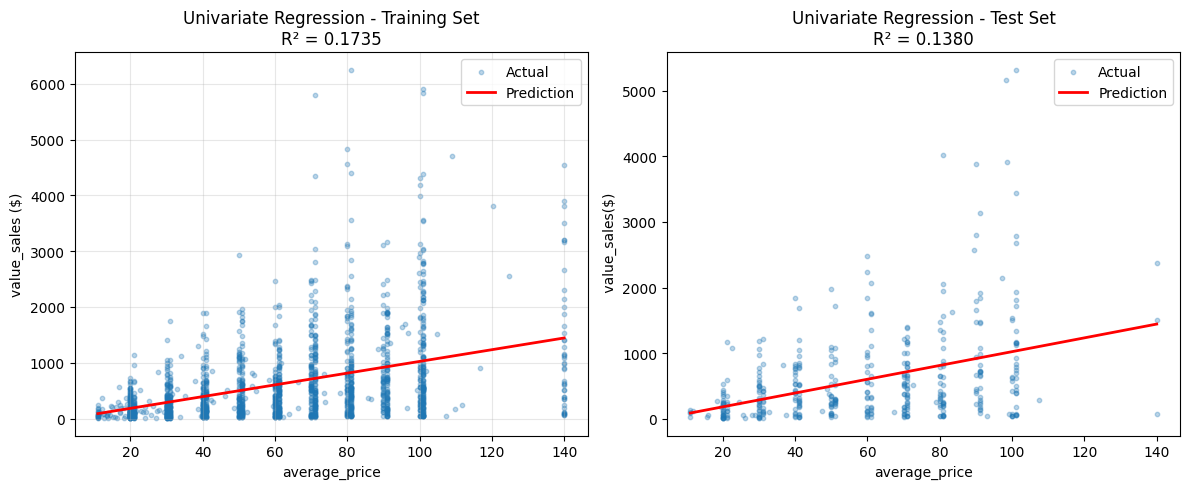

In [10]:
# Training data
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
plt.scatter(X_train_uni, y_train, alpha=0.3, s=10, label='Actual') 
# FIXED: Create a sorted version for the line 
X_train_sorted = X_train_uni.sort_values('average_price') 
y_pred_sorted = uni_model.predict(X_train_sorted) 
plt.plot(X_train_sorted, y_pred_sorted, color='red', linewidth=2, 
label='Prediction') 
plt.xlabel('average_price') 
plt.ylabel('value_sales ($)') 
plt.title(f'Univariate Regression - Training Set\nR² = {train_r2:.4f}') 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.grid(True, alpha=0.3) 
# Test data 
plt.subplot(1, 2, 2) 
plt.scatter(X_test_uni, y_test, alpha=0.3, s=10, label='Actual') 
# FIXED: Create a sorted version for the line 
X_test_sorted = X_test_uni.sort_values('average_price') 
y_pred_test_sorted = uni_model.predict(X_test_sorted) 
plt.plot(X_test_sorted, y_pred_test_sorted, color='red', linewidth=2, 
label='Prediction') 
plt.xlabel('average_price') 
plt.ylabel(' value_sales($)') #sales_Value
plt.title(f'Univariate Regression - Test Set\nR² = {test_r2:.4f}') 
plt.legend() 
plt.tight_layout() 
plt.show() 


In [11]:
# Select features for multivariate regression 
feature_cols = ['average_price', 'volume_sales', 'year',  
'month', 'city', 'manufacturer', 'brand',  
'class', 'price_bracket'] 
X_multivariate = df[feature_cols] 
y = df['value_sales'] 
print(f"Selected features: {feature_cols}") 
print(f"\nFeature matrix shape: {X_multivariate.shape}")


Selected features: ['average_price', 'volume_sales', 'year', 'month', 'city', 'manufacturer', 'brand', 'class', 'price_bracket']

Feature matrix shape: (2000, 9)


In [12]:
categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

# Apply label encoding
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    X_multivariate[col] = encoder.fit_transform(X_multivariate[col])
    label_encoders[col] = encoder

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


C:\Users\j\AppData\Local\Temp\ipykernel_5624\1104106755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_multivariate[col] = encoder.fit_transform(X_multivariate[col])
C:\Users\j\AppData\Local\Temp\ipykernel_5624\1104106755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_multivariate[col] = encoder.fit_transform(X_multivariate[col])
C:\Users\j\AppData\Local\Temp\ipykernel_5624\1104106755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [13]:
print(X_multivariate.head())

   average_price  volume_sales  year  month  city  manufacturer  brand  class  \
0           27.6          30.1  2024     12     1             5      3      1   
1           41.0           9.1  2024     10     2             6      4      0   
2          101.0           1.7  2023      1     8             0      0      3   
3           61.0          20.1  2022      2     3             6      5      2   
4           81.0          12.3  2024      2     5             3      5      4   

   price_bracket  
0              2  
1              4  
2              0  
3              6  
4              8  


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multivariate,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# -----------------------------------
# 1. Split the data
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_multivariate,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# 2. Scale the features
# -----------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# -----------------------------------
# 3. Create the multivariate model
# -----------------------------------

multivariate_model = LinearRegression()

# -----------------------------------
# 4. Train the model
# -----------------------------------

multivariate_model.fit(X_train_scaled, y_train)

# -----------------------------------
# 5. Make predictions
# -----------------------------------

y_train_pred = multivariate_model.predict(X_train_scaled)

y_test_pred = multivariate_model.predict(X_test_scaled)

# -----------------------------------
# 6. Calculate RMSE
# -----------------------------------

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

# -----------------------------------
# 7. Calculate R² Score
# -----------------------------------

train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)

# -----------------------------------
# 8. Display results
# -----------------------------------

print("Multivariate Model Performance:")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Test R² Score: {test_r2:.4f}")

Multivariate Model Performance:
Training RMSE: $283.53
Test RMSE: $296.47
Training R² Score: 0.8596
Test R² Score: 0.8332


In [18]:
# ============================================
# RIDGE REGRESSION - MULTIVARIATE ML
# Oil Sales Dataset
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

df = pd.read_csv("oil_sales_assignment_dataset.csv")


# --------------------------------------------
# 3. Select Features
# --------------------------------------------

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X_multivariate = df[feature_cols].copy()

# Target variable
y = df['value_sales']


print("Selected features:")
print(feature_cols)

print("\nFeature matrix shape:")
print(X_multivariate.shape)


# --------------------------------------------
# 4. Label Encoding
# --------------------------------------------

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X_multivariate[col] = encoder.fit_transform(
        X_multivariate[col].astype(str)
    )

    label_encoders[col] = encoder


print("\nData after Label Encoding:")
print(X_multivariate.head())


# --------------------------------------------
# 5. Split Data into Training and Testing
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_multivariate,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)


# --------------------------------------------
# 6. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)


# --------------------------------------------
# 7. Create Ridge Regression Model
# --------------------------------------------

ridge_model = Ridge(
    alpha=1.0
)


# --------------------------------------------
# 8. Train the Ridge Model
# --------------------------------------------

ridge_model.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------
# 9. Make Predictions
# --------------------------------------------

y_train_pred = ridge_model.predict(
    X_train_scaled
)

y_test_pred = ridge_model.predict(
    X_test_scaled
)


# --------------------------------------------
# 10. Calculate RMSE
# --------------------------------------------

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)


# --------------------------------------------
# 11. Calculate R² Score
# --------------------------------------------

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# --------------------------------------------
# 12. Display Model Performance
# --------------------------------------------

print("\n============================================")
print("RIDGE REGRESSION MODEL PERFORMANCE")
print("============================================")

print(f"Training RMSE: ${train_rmse:,.2f}")

print(f"Test RMSE: ${test_rmse:,.2f}")

print(f"Training R² Score: {train_r2:.4f}")

print(f"Test R² Score: {test_r2:.4f}")

Selected features:
['average_price', 'volume_sales', 'year', 'month', 'city', 'manufacturer', 'brand', 'class', 'price_bracket']

Feature matrix shape:
(2000, 9)

Data after Label Encoding:
   average_price  volume_sales  year  month  city  manufacturer  brand  class  \
0           27.6          30.1  2024     12     1             5      3      1   
1           41.0           9.1  2024     10     2             6      4      0   
2          101.0           1.7  2023      1     8             0      0      3   
3           61.0          20.1  2022      2     3             6      5      2   
4           81.0          12.3  2024      2     5             3      5      4   

   price_bracket  
0              2  
1              4  
2              0  
3              6  
4              8  

Training data shape:
(1600, 9)

Testing data shape:
(400, 9)

RIDGE REGRESSION MODEL PERFORMANCE
Training RMSE: $283.53
Test RMSE: $296.42
Training R² Score: 0.8596
Test R² Score: 0.8333


In [20]:
# ============================================
# LASSO REGRESSION - MULTIVARIATE ML
# Oil Sales Dataset
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

df = pd.read_csv("oil_sales_assignment_dataset.csv")


# --------------------------------------------
# 3. Select Features
# --------------------------------------------

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X_multivariate = df[feature_cols].copy()

# Target variable
y = df['value_sales']


print("Selected features:")
print(feature_cols)

print("\nFeature matrix shape:")
print(X_multivariate.shape)


# --------------------------------------------
# 4. Label Encoding
# --------------------------------------------

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X_multivariate[col] = encoder.fit_transform(
        X_multivariate[col].astype(str)
    )

    label_encoders[col] = encoder


print("\nData after Label Encoding:")
print(X_multivariate.head())


# --------------------------------------------
# 5. Split Data into Training and Testing
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_multivariate,
    y,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------
# 6. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)


# --------------------------------------------
# 7. Create Lasso Regression Model
# --------------------------------------------

lasso_model = Lasso(
    alpha=1.0,
    max_iter=10000
)


# --------------------------------------------
# 8. Train the Lasso Model
# --------------------------------------------

lasso_model.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------
# 9. Make Predictions
# --------------------------------------------

y_train_pred = lasso_model.predict(
    X_train_scaled
)

y_test_pred = lasso_model.predict(
    X_test_scaled
)


# --------------------------------------------
# 10. Calculate RMSE
# --------------------------------------------

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)


# --------------------------------------------
# 11. Calculate R² Score
# --------------------------------------------

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# --------------------------------------------
# 12. Display Model Performance
# --------------------------------------------

print("\n============================================")
print("LASSO REGRESSION MODEL PERFORMANCE")
print("============================================")

print(f"Training RMSE: ${train_rmse:,.2f}")

print(f"Test RMSE: ${test_rmse:,.2f}")

print(f"Training R² Score: {train_r2:.4f}")

print(f"Test R² Score: {test_r2:.4f}")

Selected features:
['average_price', 'volume_sales', 'year', 'month', 'city', 'manufacturer', 'brand', 'class', 'price_bracket']

Feature matrix shape:
(2000, 9)

Data after Label Encoding:
   average_price  volume_sales  year  month  city  manufacturer  brand  class  \
0           27.6          30.1  2024     12     1             5      3      1   
1           41.0           9.1  2024     10     2             6      4      0   
2          101.0           1.7  2023      1     8             0      0      3   
3           61.0          20.1  2022      2     3             6      5      2   
4           81.0          12.3  2024      2     5             3      5      4   

   price_bracket  
0              2  
1              4  
2              0  
3              6  
4              8  

LASSO REGRESSION MODEL PERFORMANCE
Training RMSE: $283.54
Test RMSE: $296.26
Training R² Score: 0.8596
Test R² Score: 0.8335


In [21]:
# ============================================
# SUPPORT VECTOR REGRESSION (SVR)
# Oil Sales Dataset
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

df = pd.read_csv("oil_sales_assignment_dataset.csv")


# --------------------------------------------
# 3. Select Features
# --------------------------------------------

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X_multivariate = df[feature_cols].copy()

# Target variable
y = df['value_sales']


# --------------------------------------------
# 4. Label Encoding
# --------------------------------------------

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X_multivariate[col] = encoder.fit_transform(
        X_multivariate[col].astype(str)
    )

    label_encoders[col] = encoder


# --------------------------------------------
# 5. Split Data
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_multivariate,
    y,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------
# 6. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# --------------------------------------------
# 7. Create SVR Model
# --------------------------------------------

svr_model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma='scale'
)


# --------------------------------------------
# 8. Train the Model
# --------------------------------------------

svr_model.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------
# 9. Make Predictions
# --------------------------------------------

y_train_pred = svr_model.predict(
    X_train_scaled
)

y_test_pred = svr_model.predict(
    X_test_scaled
)


# --------------------------------------------
# 10. Calculate RMSE
# --------------------------------------------

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)


# --------------------------------------------
# 11. Calculate R² Score
# --------------------------------------------

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# --------------------------------------------
# 12. Display Results
# --------------------------------------------

print("\n============================================")
print("SVR MODEL PERFORMANCE")
print("============================================")

print(f"Training RMSE: ${train_rmse:,.2f}")

print(f"Test RMSE: ${test_rmse:,.2f}")

print(f"Training R² Score: {train_r2:.4f}")

print(f"Test R² Score: {test_r2:.4f}")


SVR MODEL PERFORMANCE
Training RMSE: $367.70
Test RMSE: $343.58
Training R² Score: 0.7638
Test R² Score: 0.7760


In [22]:
# ============================================
# PERCEPTRON CLASSIFIER
# Oil Sales Dataset
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# --------------------------------------------
# 3. Select Features
# --------------------------------------------

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()


# --------------------------------------------
# 4. Create Classification Target
# --------------------------------------------

# Use the median value_sales as the threshold

sales_threshold = df['value_sales'].median()

y = (
    df['value_sales'] >= sales_threshold
).astype(int)


print("Sales threshold:")
print(sales_threshold)

print("\nTarget distribution:")
print(y.value_counts())


# --------------------------------------------
# 5. Label Encoding
# --------------------------------------------

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# --------------------------------------------
# 6. Split Data
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------
# 7. Feature Scaling
# --------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# --------------------------------------------
# 8. Create Perceptron Model
# --------------------------------------------

perceptron_model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)


# --------------------------------------------
# 9. Train the Model
# --------------------------------------------

perceptron_model.fit(
    X_train_scaled,
    y_train
)


# --------------------------------------------
# 10. Make Predictions
# --------------------------------------------

y_train_pred = perceptron_model.predict(
    X_train_scaled
)

y_test_pred = perceptron_model.predict(
    X_test_scaled
)


# --------------------------------------------
# 11. Evaluate the Model
# --------------------------------------------

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)


# --------------------------------------------
# 12. Display Performance
# --------------------------------------------

print("\n============================================")
print("PERCEPTRON MODEL PERFORMANCE")
print("============================================")

print(
    f"Training Accuracy: "
    f"{train_accuracy:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy:.4f}"
)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred
    )
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)

Sales threshold:
368.32

Target distribution:
value_sales
1    1000
0    1000
Name: count, dtype: int64

PERCEPTRON MODEL PERFORMANCE
Training Accuracy: 0.9131
Test Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       200
           1       0.90      0.95      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.92       400
weighted avg       0.93      0.93      0.92       400


Confusion Matrix:
[[179  21]
 [  9 191]]


In [23]:
# ============================================
# RANDOM FOREST REGRESSION
# Oil Sales Dataset
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# --------------------------------------------
# 3. Select Features
# --------------------------------------------

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

# Target variable
y = df['value_sales']


# --------------------------------------------
# 4. Label Encoding
# --------------------------------------------

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# --------------------------------------------
# 5. Split Data
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------
# 6. Create Random Forest Model
# --------------------------------------------

rf_model = RandomForestRegressor(

    n_estimators=100,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=1,

    random_state=42,

    n_jobs=-1
)


# --------------------------------------------
# 7. Train the Model
# --------------------------------------------

rf_model.fit(
    X_train,
    y_train
)


# --------------------------------------------
# 8. Make Predictions
# --------------------------------------------

y_train_pred = rf_model.predict(
    X_train
)

y_test_pred = rf_model.predict(
    X_test
)


# --------------------------------------------
# 9. Calculate RMSE
# --------------------------------------------

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)


# --------------------------------------------
# 10. Calculate R² Score
# --------------------------------------------

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# --------------------------------------------
# 11. Display Model Performance
# --------------------------------------------

print("\n============================================")
print("RANDOM FOREST REGRESSION PERFORMANCE")
print("============================================")

print(
    f"Training RMSE: "
    f"${train_rmse:,.2f}"
)

print(
    f"Test RMSE: "
    f"${test_rmse:,.2f}"
)

print(
    f"Training R² Score: "
    f"{train_r2:.4f}"
)

print(
    f"Test R² Score: "
    f"{test_r2:.4f}"
)


RANDOM FOREST REGRESSION PERFORMANCE
Training RMSE: $29.49
Test RMSE: $67.38
Training R² Score: 0.9985
Test R² Score: 0.9914


In [24]:
# ============================================
# GRADIENT BOOSTING REGRESSION (GBM)
# Oil Sales Dataset
# ============================================

# --------------------------------------------
# 1. Import Libraries
# --------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# --------------------------------------------
# 2. Load Dataset
# --------------------------------------------

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# --------------------------------------------
# 3. Select Features
# --------------------------------------------

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

# Target variable
y = df['value_sales']


# --------------------------------------------
# 4. Label Encoding
# --------------------------------------------

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# --------------------------------------------
# 5. Split Data
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------
# 6. Create GBM Model
# --------------------------------------------

gbm_model = GradientBoostingRegressor(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=3,

    min_samples_split=2,

    min_samples_leaf=1,

    random_state=42,

    loss='squared_error'
)


# --------------------------------------------
# 7. Train the Model
# --------------------------------------------

gbm_model.fit(
    X_train,
    y_train
)


# --------------------------------------------
# 8. Make Predictions
# --------------------------------------------

y_train_pred = gbm_model.predict(
    X_train
)

y_test_pred = gbm_model.predict(
    X_test
)


# --------------------------------------------
# 9. Calculate RMSE
# --------------------------------------------

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)


# --------------------------------------------
# 10. Calculate R² Score
# --------------------------------------------

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# --------------------------------------------
# 11. Display Results
# --------------------------------------------

print("\n============================================")
print("GRADIENT BOOSTING REGRESSION PERFORMANCE")
print("============================================")

print(
    f"Training RMSE: "
    f"${train_rmse:,.2f}"
)

print(
    f"Test RMSE: "
    f"${test_rmse:,.2f}"
)

print(
    f"Training R² Score: "
    f"{train_r2:.4f}"
)

print(
    f"Test R² Score: "
    f"{test_r2:.4f}"
)


GRADIENT BOOSTING REGRESSION PERFORMANCE
Training RMSE: $30.65
Test RMSE: $67.56
Training R² Score: 0.9984
Test R² Score: 0.9913


In [25]:
# ============================================
# COMPARE ALL REGRESSION MODELS
# ============================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# ============================================
# 1. Load Dataset
# ============================================

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# ============================================
# 2. Select Features
# ============================================

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

y = df['value_sales']


# ============================================
# 3. Label Encoding
# ============================================

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# ============================================
# 4. Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)


# ============================================
# 5. Scale Data
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================
# 6. Create Models
# ============================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10000
    ),

    "SVR": SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1,
        gamma='scale'
    ),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=3,

        random_state=42
    )
}


# ============================================
# 7. Train and Evaluate Models
# ============================================

results = []


for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # Models that require scaling
    if model_name in [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "SVR"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_train_pred = model.predict(
            X_train_scaled
        )

        y_test_pred = model.predict(
            X_test_scaled
        )

    # Tree-based models do not require scaling
    else:

        model.fit(
            X_train,
            y_train
        )

        y_train_pred = model.predict(
            X_train
        )

        y_test_pred = model.predict(
            X_test
        )


    # Calculate RMSE
    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    # Calculate R²
    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    # Save results
    results.append({

        "Model": model_name,

        "Training RMSE": train_rmse,

        "Test RMSE": test_rmse,

        "Training R²": train_r2,

        "Test R²": test_r2
    })


# ============================================
# 8. Create Comparison Table
# ============================================

results_df = pd.DataFrame(
    results
)


# ============================================
# 9. Sort by Test RMSE
# ============================================

results_df = results_df.sort_values(
    by="Test RMSE",
    ascending=True
)


# ============================================
# 10. Display Results
# ============================================

print("\n============================================")
print("MODEL COMPARISON")
print("============================================")

print(
    results_df.to_string(
        index=False
    )
)


Training Linear Regression...

Training Ridge Regression...

Training Lasso Regression...

Training SVR...

Training Random Forest...

Training Gradient Boosting...

MODEL COMPARISON
            Model  Training RMSE  Test RMSE  Training R²  Test R²
    Random Forest      29.488563  67.376544     0.998481 0.991387
Gradient Boosting      30.649695  67.555157     0.998359 0.991341
 Lasso Regression     283.543921 296.264255     0.859561 0.833470
 Ridge Regression     283.528321 296.423593     0.859577 0.833291
Linear Regression     283.527990 296.467283     0.859577 0.833242
              SVR     367.698297 343.577388     0.763827 0.776034


In [26]:
# ============================================
# COMPARE ALL REGRESSION MODELS
# WITHOUT FEATURE SCALING
# ============================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# ============================================
# 1. Load Dataset
# ============================================

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# ============================================
# 2. Select Features
# ============================================

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

y = df['value_sales']


# ============================================
# 3. Label Encoding
# ============================================

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# ============================================
# 4. Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)


# ============================================
# 5. Create Models
# ============================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10000
    ),

    "SVR": SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1,
        gamma='scale'
    ),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=3,

        random_state=42
    )
}


# ============================================
# 6. Train and Evaluate Models
# ============================================

results = []


for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # Train model
    model.fit(
        X_train,
        y_train
    )

    # Training predictions
    y_train_pred = model.predict(
        X_train
    )

    # Testing predictions
    y_test_pred = model.predict(
        X_test
    )


    # -----------------------------
    # RMSE
    # -----------------------------

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    # -----------------------------
    # R² Score
    # -----------------------------

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    # Save results
    results.append({

        "Model": model_name,

        "Training RMSE": train_rmse,

        "Test RMSE": test_rmse,

        "Training R²": train_r2,

        "Test R²": test_r2
    })


# ============================================
# 7. Create Results DataFrame
# ============================================

results_df = pd.DataFrame(
    results
)


# ============================================
# 8. Sort by Test RMSE
# ============================================

results_df = results_df.sort_values(

    by="Test RMSE",

    ascending=True
)


# ============================================
# 9. Display Results
# ============================================

print("\n============================================")
print("MODEL COMPARISON WITHOUT SCALING")
print("============================================")

print(
    results_df.to_string(
        index=False
    )
)


Training Linear Regression...

Training Ridge Regression...

Training Lasso Regression...

Training SVR...

Training Random Forest...

Training Gradient Boosting...

MODEL COMPARISON WITHOUT SCALING
            Model  Training RMSE  Test RMSE  Training R²   Test R²
    Random Forest      29.488563  67.376544     0.998481  0.991387
Gradient Boosting      30.649695  67.555157     0.998359  0.991341
 Lasso Regression     283.530313 296.401954     0.859575  0.833316
 Ridge Regression     283.527990 296.466580     0.859577  0.833243
Linear Regression     283.527990 296.467283     0.859577  0.833242
              SVR     780.592278 750.282070    -0.064376 -0.068027


In [27]:
# ============================================
# COMPARE ALL REGRESSION MODELS
# USING MIN-MAX SCALING
# ============================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# ============================================
# 1. Load Dataset
# ============================================

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# ============================================
# 2. Select Features
# ============================================

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

y = df['value_sales']


# ============================================
# 3. Label Encoding
# ============================================

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# ============================================
# 4. Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)


# ============================================
# 5. Min-Max Scaling
# ============================================

scaler = MinMaxScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(
    X_test
)


# ============================================
# 6. Create Models
# ============================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10000
    ),

    "SVR": SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1,
        gamma='scale'
    ),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=3,

        random_state=42
    )
}


# ============================================
# 7. Train and Evaluate Models
# ============================================

results = []


for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # Train model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Training predictions
    y_train_pred = model.predict(
        X_train_scaled
    )

    # Testing predictions
    y_test_pred = model.predict(
        X_test_scaled
    )


    # ----------------------------------------
    # RMSE
    # ----------------------------------------

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    # ----------------------------------------
    # R² Score
    # ----------------------------------------

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    # Store results
    results.append({

        "Model": model_name,

        "Training RMSE": train_rmse,

        "Test RMSE": test_rmse,

        "Training R²": train_r2,

        "Test R²": test_r2
    })


# ============================================
# 8. Create Comparison DataFrame
# ============================================

results_df = pd.DataFrame(
    results
)


# ============================================
# 9. Sort by Test RMSE
# ============================================

results_df = results_df.sort_values(

    by="Test RMSE",

    ascending=True
)


# ============================================
# 10. Display Results
# ============================================

print("\n============================================")
print("MODEL COMPARISON USING MIN-MAX SCALING")
print("============================================")

print(
    results_df.to_string(
        index=False
    )
)


Training Linear Regression...

Training Ridge Regression...

Training Lasso Regression...

Training SVR...

Training Random Forest...

Training Gradient Boosting...

MODEL COMPARISON USING MIN-MAX SCALING
            Model  Training RMSE  Test RMSE  Training R²  Test R²
    Random Forest      29.490349  66.813382     0.998481 0.991530
Gradient Boosting      30.649695  67.552020     0.998359 0.991342
 Ridge Regression     284.721988 294.028958     0.858392 0.835974
 Lasso Regression     283.787295 295.254620     0.859320 0.834603
Linear Regression     283.527990 296.467283     0.859577 0.833242
              SVR     433.504079 409.358397     0.671729 0.682063


In [28]:
# ============================================
# COMPARE ALL REGRESSION MODELS
# USING MIN-MAX SCALING
# ============================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


# ============================================
# 1. Load Dataset
# ============================================

df = pd.read_csv(
    "oil_sales_assignment_dataset.csv"
)


# ============================================
# 2. Select Features
# ============================================

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

y = df['value_sales']


# ============================================
# 3. Label Encoding
# ============================================

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder


# ============================================
# 4. Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)


# ============================================
# 5. Min-Max Scaling
# ============================================

scaler = MinMaxScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(
    X_test
)


# ============================================
# 6. Create Models
# ============================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10000
    ),

    "SVR": SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1,
        gamma='scale'
    ),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,

        random_state=42,

        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=3,

        random_state=42
    )
}


# ============================================
# 7. Train and Evaluate Models
# ============================================

results = []


for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # Train model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Training predictions
    y_train_pred = model.predict(
        X_train_scaled
    )

    # Testing predictions
    y_test_pred = model.predict(
        X_test_scaled
    )


    # ----------------------------------------
    # RMSE
    # ----------------------------------------

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    # ----------------------------------------
    # R² Score
    # ----------------------------------------

    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    # Store results
    results.append({

        "Model": model_name,

        "Training RMSE": train_rmse,

        "Test RMSE": test_rmse,

        "Training R²": train_r2,

        "Test R²": test_r2
    })


# ============================================
# 8. Create Comparison DataFrame
# ============================================

results_df = pd.DataFrame(
    results
)


# ============================================
# 9. Sort by Test RMSE
# ============================================

results_df = results_df.sort_values(

    by="Test RMSE",

    ascending=True
)


# ============================================
# 10. Display Results
# ============================================

print("\n============================================")
print("MODEL COMPARISON USING MIN-MAX SCALING")
print("============================================")

print(
    results_df.to_string(
        index=False
    )
)


Training Linear Regression...

Training Ridge Regression...

Training Lasso Regression...

Training SVR...

Training Random Forest...

Training Gradient Boosting...

MODEL COMPARISON USING MIN-MAX SCALING
            Model  Training RMSE  Test RMSE  Training R²  Test R²
    Random Forest      29.490349  66.813382     0.998481 0.991530
Gradient Boosting      30.649695  67.552020     0.998359 0.991342
 Ridge Regression     284.721988 294.028958     0.858392 0.835974
 Lasso Regression     283.787295 295.254620     0.859320 0.834603
Linear Regression     283.527990 296.467283     0.859577 0.833242
              SVR     433.504079 409.358397     0.671729 0.682063


In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import mean_squared_error, r2_score


# ============================================
# 1. Load Dataset
# ============================================

df = pd.read_csv("oil_sales_assignment_dataset.csv")


# ============================================
# 2. Select Features
# ============================================

feature_cols = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

X = df[feature_cols].copy()

y = df['value_sales']


# ============================================
# 3. Define Categorical Columns
# ============================================

categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]


# ============================================
# 4. One-Hot Encode Categorical Columns
# ============================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            'categorical',

            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),

            categorical_cols
        )
    ],

    remainder='passthrough'
)


# ============================================
# 5. Split Data
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)


# ============================================
# 6. One-Hot Encoding
# ============================================

X_train_encoded = preprocessor.fit_transform(
    X_train
)

X_test_encoded = preprocessor.transform(
    X_test
)


# ============================================
# 7. Scale ALL Features
# ============================================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(
    X_train_encoded
)

X_test_scaled = scaler.transform(
    X_test_encoded
)


# ============================================
# 8. Models
# ============================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10000
    ),

    "SVR": SVR(
        kernel='rbf',
        C=100,
        epsilon=0.1
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}


# ============================================
# 9. Train and Compare
# ============================================

results = []


for model_name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    y_train_pred = model.predict(
        X_train_scaled
    )

    y_test_pred = model.predict(
        X_test_scaled
    )


    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )


    train_r2 = r2_score(
        y_train,
        y_train_pred
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )


    results.append({

        "Model": model_name,

        "Training RMSE": train_rmse,

        "Test RMSE": test_rmse,

        "Training R²": train_r2,

        "Test R²": test_r2
    })


# ============================================
# 10. Display Comparison
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test RMSE"
)

print(results_df.to_string(index=False))

            Model  Training RMSE  Test RMSE  Training R²  Test R²
    Random Forest      32.358143  55.443493     0.998171 0.994168
Gradient Boosting      30.776783  59.114215     0.998345 0.993370
 Ridge Regression     282.842217 295.399617     0.860255 0.834441
 Lasso Regression     282.089911 295.923411     0.860998 0.833853
Linear Regression     281.418598 297.827629     0.861659 0.831708
              SVR     624.212472 626.284725     0.319369 0.255822
